# Step 3: Geo-intervention Generation

## Libaries

In [1]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/rrwen/Desktop/geointerv-paper/tmp/venv/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/rrwen/Desktop/geointerv-paper/src/case-study/modules/data.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 

## Folders

Create folders for storing models and related data.

In [2]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Load Best Model

In [3]:
# Create dict for best model
models = {}
geodata = {}
opt_model = 'tpot_80'

# Determine size and model type based on name
model_type = opt_model.split('_')[0]
size = int(opt_model.split('_')[1])
    
# Load data
print(f'Processing geogrid_to_{size}...')
xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')
x = pd.DataFrame(xraw.drop(columns='geometry'))
ycol = 'collisions_count'
geodata[f'geogrid_to_{size}'] = xraw
    
# Columns to remove from input data
startswith = ['collisions']

# Drop columns except target col
drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
x = x.drop(columns=drop)
    
# Load autosklearn model
if model_type == 'autosklearn':
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    print(f'Loading autosklearn_{size}...')
    with open(ask_file, 'rb') as f:
        ask = load(f)
    models[opt_model] = ask
    
# Load tpot model
if model_type == 'tpot':
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    print(f'Loading tpot_{size}...')
    tpt = geoint.models.AutoMLModel('TPOTRegressor')
    with open(tpt_file, 'rb') as f:
        tpt.model = load(f)
    tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
    tpt.last_y = x[ycol]
    tpt.predict()
    models[opt_model] = tpt

print('Done!')

Processing geogrid_to_80...
Loading tpot_80...
Done!


## Optimization

In [4]:
opt_results = {
    'scenario': [],
    'original': [],
    'optimized': [],
    'model': []
}

### Scenario 1

Create geo-interventions by optimizing transit shelters, red light cameras, schools, and watch your speed program signs in grid cells with higher than average westbound car traffic.

In [6]:
# Define local constraints
lconstr1 = {
    'transit_shelters_count': {'query': 'traffic_wb_cars_r_sum >= traffic_wb_cars_r_sum.mean()'},
    'red_light_cams_count': {'query': 'traffic_wb_cars_r_sum >= traffic_wb_cars_r_sum.mean()'},
    'schools_count': {'query': 'traffic_wb_cars_r_sum >= traffic_wb_cars_r_sum.mean()'},
    'wys_count': {'query': 'traffic_wb_cars_r_sum >= traffic_wb_cars_r_sum.mean()'}
}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt1_file = f'{model_folder}/{opt_model}_opt1.pkl'
if Path(opt1_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt1_file, 'rb') as f:
        opt1_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt1 = geoint.optimization.Optimizer(models[opt_model], lconstr1, 'BayesianOptimization', verbose=0, ymax=False)
    opt1.optimize(n_iter=10)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt1_results = {
        'original': [sum(opt1.model.last_y)],
        'optimized': [opt1.optimal_y],
        'optimal': opt1.optimal,
        'optimal_params': opt1.optimal_params,
        'optimal_details': opt1.optimal_details,
        'params': opt1.optimizer_params
    }
    with open(opt1_file, 'wb') as f:
        dump(opt1_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 1: Higher than avg westbound car traffic']
opt_results['original'] += opt1_results['original']
opt_results['optimized'] += opt1_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for tpot_80...
Running optimization for tpot_80...
Saving optimization for tpot_80...
Done!


### Scenario 2

Create geo-interventions by optimizing transit shelters, red light cameras, schools, and watch your speed program signs in grid cells with lower than average transit shelters, red light cameras, schools, and watch your speed program signs respectively.

In [8]:
# Define local constraints
lconstr2 = {
    'transit_shelters_count': {'query': 'transit_shelters_count < transit_shelters_count.mean()'},
    'red_light_cams_count': {'query': 'red_light_cams_count < red_light_cams_count.mean()'},
    'schools_count': {'query': 'schools_count < schools_count.mean()'},
    'wys_count': {'query': 'wys_count < wys_count.mean()'}
}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt2_file = f'{model_folder}/{opt_model}_opt2.pkl'
if Path(opt2_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt2_file, 'rb') as f:
        opt2_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt2 = geoint.optimization.Optimizer(models[opt_model], lconstr2, 'BayesianOptimization', verbose=0, ymax=False)
    opt2.optimize(n_iter=10)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt2_results = {
        'original': [sum(opt2.model.last_y)],
        'optimized': [opt2.optimal_y],
        'optimal': opt2.optimal,
        'optimal_params': opt2.optimal_params,
        'optimal_details': opt2.optimal_details,
        'params': opt2.optimizer_params
    }
    with open(opt2_file, 'wb') as f:
        dump(opt2_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 2: Modify scarce intervention cells']
opt_results['original'] += opt2_results['original']
opt_results['optimized'] += opt2_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for tpot_80...
Running optimization for tpot_80...
Saving optimization for tpot_80...
Done!


### Optimization Results

In [9]:
#opt_results = pd.DataFrame(opt_results)
#opt_results['diff'] = opt_results.optimized - opt_results.original
#opt_results

## Generated Geo-interventions

In [10]:
# Read data for selected model
gdata = geodata['geogrid_to_80'].copy()
gcols = [
    'transit_shelters_count',
    'red_light_cams_count',
    'schools_count',
    'wys_count'
]

# Get optimal parameters
optimalp = {
    'opt1': opt1_results['optimal_params'],
    'opt2': opt2_results['optimal_params'],
}

# Get params used for optimization
opt_params = {
    'opt1': opt1_results['params'],
    'opt2': opt2_results['params']
}
for k in opt_params:
    opt_params[k].index.name = None
    
# Set params to optimal params
for k in opt_params:
    opt_params[k]['value_optimal'] = opt_params[k]['value_orig']
    opt_params[k].loc[optimalp[k].keys(), 'value_optimal'] = list(optimalp[k].values())

In [11]:
# Set data to optimal params
for k in opt_params:
    params = opt_params[k]
    for c in params.column.unique():
        p = params[params.column == c]
        oc = f'{c}_{k}'
        gdata[oc] = gdata[c].copy()
        gdata.loc[p.row, oc] = p.value_optimal.tolist()
        gdata[f'{oc}_diff'] = gdata[oc] - gdata[c]

In [22]:
gdata[[c + '_opt1' for c in gcols] + [ycol]].head(100)

,transit_shelters_count_opt1,red_light_cams_count_opt1,schools_count_opt1,wys_count_opt1,collisions_count
0,0.000000,0.000000,0.000000,0.000000,0.0
1,0.000000,0.000000,0.000000,0.000000,0.0
2,0.000000,0.000000,0.000000,0.000000,0.0
3,0.000000,0.000000,0.000000,0.000000,0.0
4,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...
95,1.000000,0.000000,0.000000,0.000000,16.0
96,14.001445,3.195849,0.964044,4.942193,164.0
97,0.000000,0.000000,0.000000,0.000000,0.0
98,0.000000,0.000000,0.000000,0.000000,0.0


### Optimization Parameters

In [13]:
#opt_params['opt1']

In [14]:
len(opt_params['opt1'].index)

3504

In [15]:
#opt_params['opt2']

In [16]:
len(opt_params['opt2'].index)

17058

### Geo-intervention Maps (Vertical)

Scenario 1

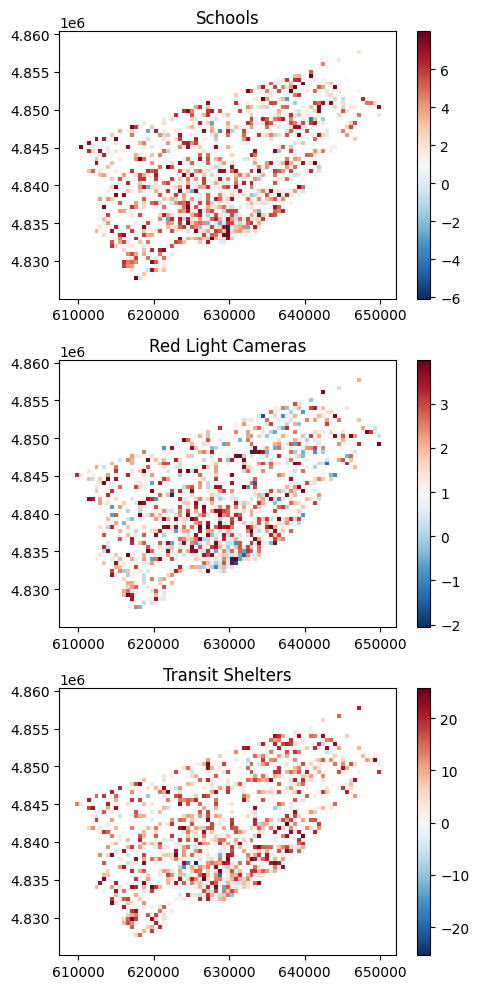

In [17]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Red light cams
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='schools_count_opt1_diff', legend=True)
ax.set_title('Schools')
ax.set_aspect('equal', adjustable='datalim')

# Red light cams
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='red_light_cams_count_opt1_diff', legend=True)
ax.set_title('Red Light Cameras')
ax.set_aspect('equal', adjustable='datalim')

# Transit shelters
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt1_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

Scenario 2

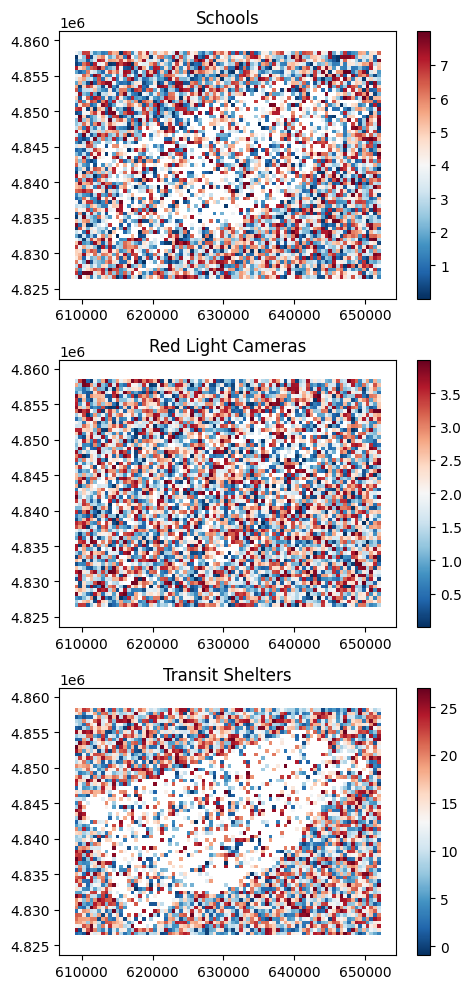

In [18]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Red light cams
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='schools_count_opt2_diff', legend=True)
ax.set_title('Schools')
ax.set_aspect('equal', adjustable='datalim')

# Red light cams
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='red_light_cams_count_opt2_diff', legend=True)
ax.set_title('Red Light Cameras')
ax.set_aspect('equal', adjustable='datalim')

# Transit shelters
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt2_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

### Geo-intervention Maps (Horizontal)

Scenario 1

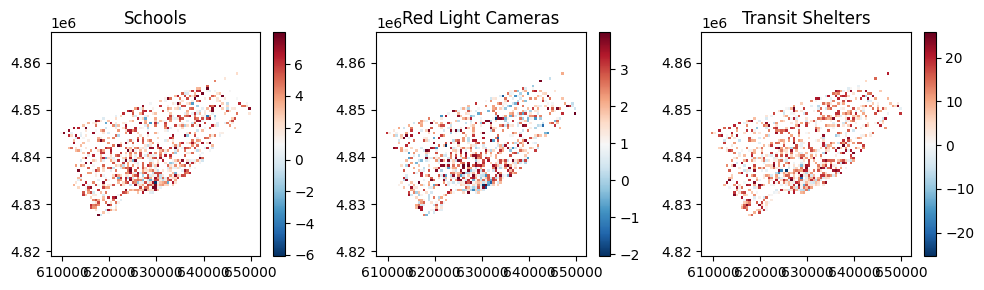

In [19]:
fig = plt.figure()
fig.set_size_inches(10, 3)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Red light cams
ax = plt.subplot(1, 3, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='schools_count_opt1_diff', legend=True)
ax.set_title('Schools')
ax.set_aspect('equal', adjustable='datalim')

# Red light cams
ax = plt.subplot(1, 3, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='red_light_cams_count_opt1_diff', legend=True)
ax.set_title('Red Light Cameras')
ax.set_aspect('equal', adjustable='datalim')

# Transit shelters
ax = plt.subplot(1, 3, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt1_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

Scenario 2

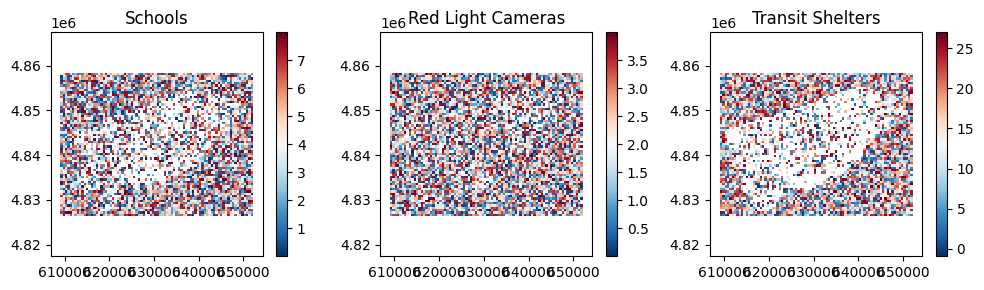

In [20]:
fig = plt.figure()
fig.set_size_inches(10, 3)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Red light cams
ax = plt.subplot(1, 3, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='schools_count_opt2_diff', legend=True)
ax.set_title('Schools')
ax.set_aspect('equal', adjustable='datalim')

# Red light cams
ax = plt.subplot(1, 3, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='red_light_cams_count_opt2_diff', legend=True)
ax.set_title('Red Light Cameras')
ax.set_aspect('equal', adjustable='datalim')

# Transit shelters
ax = plt.subplot(1, 3, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt2_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()